# DS1000 Adapter Verification v2 – Full Hallucination Pipeline (Windows Version)

Same as the basic Verify notebook (adapter-only code generation, baseline from CSV) but runs the **full hallucination pipeline** (AST, dynamic, lib_api, patch) per task and outputs a CSV with the same schema as `ds1000_pipeline_output.csv`. Windows-compatible; no quantization; GPU recommended (~6GB VRAM).

## 1. Setup

In [1]:
# Check GPU (optional; skip if no NVIDIA GPU)
import subprocess
try:
    subprocess.run(["nvidia-smi"], check=True)
except Exception as e:
    print("nvidia-smi not available:", e)
print('h')

Fri Mar 20 13:15:44 2026       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.288.01             Driver Version: 535.288.01   CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  NVIDIA RTX A4000               Off | 00000000:55:00.0 Off |                  Off |
| 41%   34C    P8              11W / 140W |     77MiB / 16376MiB |      0%      Default |
|                                         |                      |                  N/A |
+-----------------------------------------+----------------------+--

In [2]:
!pip install -q transformers peft datasets torch accelerate tqdm pandas

## 2. Paths (local: baseline CSV + lora_adapters folder or zip)

In [3]:
import os
import zipfile

# Set paths for Jupyter (default: current working directory; set NOTEBOOK_DIR if needed)
try:
    NOTEBOOK_DIR = os.path.dirname(os.path.abspath(__file__))
except NameError:
    NOTEBOOK_DIR = os.getcwd()
BASELINE_CSV_PATH = os.path.join(NOTEBOOK_DIR, "ds1000_pipeline_output.csv")
ADAPTER_ZIP_OR_DIR = os.path.join(NOTEBOOK_DIR, "lora_adapters")

# If ADAPTER_ZIP_OR_DIR is a zip file, extract it; else use as adapter folder
if os.path.isfile(ADAPTER_ZIP_OR_DIR) and ADAPTER_ZIP_OR_DIR.lower().endswith(".zip"):
    ADAPTER_PATH = os.path.join(NOTEBOOK_DIR, "lora_adapters_extracted")
    os.makedirs(ADAPTER_PATH, exist_ok=True)
    with zipfile.ZipFile(ADAPTER_ZIP_OR_DIR, "r") as z:
        z.extractall(ADAPTER_PATH)
    subdirs = [d for d in os.listdir(ADAPTER_PATH) if os.path.isdir(os.path.join(ADAPTER_PATH, d))]
    if len(subdirs) == 1 and os.path.isfile(os.path.join(ADAPTER_PATH, subdirs[0], "adapter_config.json")):
        ADAPTER_PATH = os.path.join(ADAPTER_PATH, subdirs[0])
else:
    ADAPTER_PATH = ADAPTER_ZIP_OR_DIR
    if os.path.isdir(ADAPTER_PATH):
        subdirs = [d for d in os.listdir(ADAPTER_PATH) if os.path.isdir(os.path.join(ADAPTER_PATH, d))]
        if len(subdirs) == 1 and os.path.isfile(os.path.join(ADAPTER_PATH, subdirs[0], "adapter_config.json")):
            ADAPTER_PATH = os.path.join(ADAPTER_PATH, subdirs[0])

print(f"Baseline CSV: {BASELINE_CSV_PATH}")
print(f"Adapters at: {ADAPTER_PATH}")

Baseline CSV: /home/jovyan/TT/ALL VERIFICATION/FED_AVG/ds1000_pipeline_output.csv
Adapters at: /home/jovyan/TT/ALL VERIFICATION/FED_AVG/lora_adapters


In [4]:
!cd loara_adapters

/usr/bin/sh: 1: cd: can't cd to loara_adapters


In [5]:
!ls

Verify_DS1000_Adapter_Windows.ipynb	 human_eval_sft_test.csv
Verify_HumanEval_Adapter_Colab_v2.ipynb  humaneval_pipeline_output.csv
Verify_MBPP_Adapter_Windows_v2.ipynb	 lora_adapters
ds1000_pipeline_output.csv		 mbpp_pipeline_output.csv
final_dataset_v2_test.csv


## 3. Load DS1000

In [6]:
from datasets import load_dataset
import pandas as pd

ds = load_dataset("xlangai/DS-1000")
df = pd.DataFrame(ds["test"])
df["task_id"] = [f"DS{str(i).zfill(4)}" for i in range(len(df))]
df["prompt_2"] = df["prompt"].astype(str).str.split("A:", n=1).str[0].str.strip()
print(f"DS1000 tasks: {len(df)}")

DS1000 tasks: 1000


## 4. Load baseline from CSV (optional)

In [7]:
# Load DS1000 ids from the generated 25% test split CSV (baseline + evaluation must match)
TEST_CSV_PATH = os.path.join(NOTEBOOK_DIR, "final_dataset_v2_test.csv")
df_test = pd.read_csv(TEST_CSV_PATH)
if "dataset" in df_test.columns:
    df_test = df_test[df_test["dataset"].astype(str).str.lower().eq("ds1000")].copy()
test_task_ids = df_test["task_id"].astype(str).tolist()

# Baseline pipeline outputs (filter down to the same task ids)
df_baseline = pd.read_csv(BASELINE_CSV_PATH)
df_baseline["task_id"] = df_baseline["task_id"].astype(str)
id_to_row = df_baseline.set_index("task_id").to_dict("index")
ordered_rows = []
for tid in test_task_ids:
    if tid in id_to_row:
        ordered_rows.append({**id_to_row[tid], "task_id": tid})
df_baseline = pd.DataFrame(ordered_rows)

passed_baseline = (df_baseline["status"] == "passed").sum()
total_baseline = len(df_baseline)
pass_rate_baseline = passed_baseline / total_baseline if total_baseline else 0
print(f"Baseline (from CSV, test-split ids): {passed_baseline}/{total_baseline} passed, pass@1 = {pass_rate_baseline:.2%}")

Baseline (from CSV, test-split ids): 46/250 passed, pass@1 = 18.40%


## 4b. Use same task set as baseline (fair comparison)

So that "After SFT" is evaluated on the **same tasks** as "Before SFT", we restrict `df` to the task_ids in your baseline CSV (same order). Adapter run will then use the same number of tasks (e.g. 327).

In [8]:
# Restrict to task_ids in baseline and preserve baseline order (same N for fair comparison)
df_baseline["task_id"] = df_baseline["task_id"].astype(str)
id_to_row = df.set_index("task_id").to_dict("index")
ordered_rows = []
for _, base_row in df_baseline.iterrows():
    tid = base_row["task_id"]
    if tid in id_to_row:
        ordered_rows.append({**id_to_row[tid], "task_id": tid})
if ordered_rows:
    df = pd.DataFrame(ordered_rows)
print(f"Adapter run will use same task set as baseline: {len(df)} tasks (baseline had {total_baseline})")
if len(df) < total_baseline:
    print(f"  Note: {total_baseline - len(df)} baseline rows had task_ids not in the loaded HF dataset.")
print(len(df))

Adapter run will use same task set as baseline: 250 tasks (baseline had 250)
250


In [ ]:
# Optional subset: load `ds1000/verification_task_ids.json` if present (see repo WORKING/ pack).
_cand_manifest = [
    os.path.join(NOTEBOOK_DIR, "ds1000", "verification_task_ids.json"),
    os.path.join(NOTEBOOK_DIR, "verification_task_ids.json"),
]
VERIFICATION_JSON_PATH = next((p for p in _cand_manifest if os.path.isfile(p)), _cand_manifest[0])
SUBSET_TASK_IDS = None
if os.path.isfile(VERIFICATION_JSON_PATH):
    import json
    with open(VERIFICATION_JSON_PATH, "r", encoding="utf-8") as f:
        _manifest_subset = json.load(f)
    SUBSET_TASK_IDS = _manifest_subset.get("task_ids")
    print(f"Loaded verification manifest ({len(SUBSET_TASK_IDS)} tasks): {VERIFICATION_JSON_PATH}")
else:
    print(f"No manifest at {VERIFICATION_JSON_PATH} — running full baseline task set.")

# When checking results vs manifest: use "fedavg_adapter" after FedAvg LoRA, "federroravg_adapter" after FedErrorAvg LoRA.
VERIFICATION_EXPECT_KEY = "fedavg_adapter"

if SUBSET_TASK_IDS:
    sid = [str(x) for x in SUBSET_TASK_IDS]
    df_baseline = df_baseline[df_baseline["task_id"].astype(str).isin(sid)].copy()
    df_baseline = df_baseline.set_index("task_id").loc[sid].reset_index()
    id_small = df.set_index("task_id").to_dict("index")
    ordered_rows = []
    for tid in sid:
        if tid in id_small:
            ordered_rows.append({**id_small[tid], "task_id": tid})
    df = pd.DataFrame(ordered_rows)
    passed_baseline = (df_baseline["status"] == "passed").sum()
    total_baseline = len(df_baseline)
    pass_rate_baseline = passed_baseline / total_baseline if total_baseline else 0
    print(f"Subset mode: {len(df)} tasks; baseline pass {passed_baseline}/{total_baseline} ({pass_rate_baseline:.2%})")

## 5. Generation helpers

In [9]:
import re

def construct_prompt_humaneval(docstring_prompt):
    system_message = (
        "You are an expert Python developer. Your task is to complete the function "
        "provided by the user. Follow the docstring exactly. "
        "Provide your output ONLY as a single Python code block starting with ```python."
    )
    messages = [
        {"role": "system", "content": system_message},
        {"role": "user", "content": f"Complete this Python function:\n{docstring_prompt}"}
    ]
    return messages

def extract_only_exec_context_wi(code_context):
    if code_context is None or not str(code_context).strip():
        return "import pandas as pd\nimport numpy as np"
    pattern = r'exec_context = r"""(.*?)"""'
    match = re.search(pattern, str(code_context), re.DOTALL)
    return match.group(1).strip() if match else "import pandas as pd\nimport numpy as np"

def contruct_prompt_ds1k_v4(raw_prompt, exec_context_snippet):
    system_message = (
        "You are a Python data scientist. You write concise, correct Python code for data manipulation. "
        "You prefer direct, vectorized solutions over complex logic. "
        "Provide your output ONLY as a single Python code block starting with ```python."
    )
    user_message = (
        "You are given a Python code snippet with a placeholder [insert]. Your code will be INSERTED at that position.\n\n"
        "===== EXISTING CODE =====\n" + exec_context_snippet + "\n\n"
        "===== TASK =====\n" + raw_prompt + "\n\n"
        "===== OUTPUT =====\nReturn ONLY raw Python code.\n"
    )
    return [{"role": "system", "content": system_message}, {"role": "user", "content": user_message}]

def extract_python_code_humaneval(text):
    pattern = r"```(?:python)?\n?(.*?)```"
    match = re.search(pattern, text, re.DOTALL)
    if match:
        return match.group(1).strip()
    return text.strip()

## 6. Hallucination pipeline (DS1000, self-contained)

In [10]:
import ast
import json
import re
import threading
import traceback
from typing import Any, Dict, List, Tuple, Optional

TIMEOUT_SECONDS = 10

def execute_with_timeout(func, args, timeout=TIMEOUT_SECONDS):
    result_container = {"result": None, "exception": None, "traceback": None}
    def wrapper():
        try:
            result_container["result"] = func(*args)
        except Exception as e:
            result_container["exception"] = e
            result_container["traceback"] = traceback.format_exc()
    thread = threading.Thread(target=wrapper)
    thread.daemon = True
    thread.start()
    thread.join(timeout=timeout)
    if thread.is_alive():
        gen_code = args[0] if args else ""
        return {"status": "failed", "error_type": "TimeoutError", "error_message": "Execution exceeded timeout", "line_number": "", "test_case": "", "testcase_output": "", "generated_code": gen_code}
    if result_container["exception"] is not None:
        e = result_container["exception"]
        is_assertion_error = isinstance(e, AssertionError)
        is_syntax_error = isinstance(e, SyntaxError)
        tb = traceback.extract_tb(e.__traceback__)
        full_traceback = result_container["traceback"] or ""
        line_num = "" if is_assertion_error else (extract_syntax_error_line(str(e)) if is_syntax_error else (min((f.lineno for f in tb if '<string>' in f.filename), default="") if [f for f in tb if '<string>' in f.filename] else ""))
        gen_code = args[0] if args else ""
        return {"status": "failed", "error_type": type(e).__name__, "error_message": str(e), "line_number": str(line_num) if line_num else "", "test_case": "", "testcase_output": full_traceback if is_assertion_error else "", "generated_code": gen_code}
    if result_container["result"] is not None:
        return result_container["result"]
    gen_code = args[0] if args else ""
    return {"status": "failed", "error_type": "UnknownError", "error_message": "No result returned", "line_number": "", "test_case": "", "testcase_output": "", "generated_code": gen_code}

def extract_syntax_error_line(error_message: str) -> str:
    match = re.search(r'\(<string>,\s*line\s+(\d+)\)', error_message)
    return match.group(1) if match else ""

def serialize_value(value: Any, max_length: int = 500) -> str:
    try:
        if value is None:
            return "None"
        if isinstance(value, (dict, list, tuple)):
            result = str(value)
        else:
            result = str(value)
        return result[:max_length] + "...[truncated]" if len(result) > max_length else result
    except Exception as e:
        return f"<Serialization Error: {str(e)}>"

def extract_ds1000_test_cases(generated_code: str, code_context: str) -> List[List[str]]:
    test_cases_data = []
    try:
        test_env = {}
        exec(code_context, test_env)
        if 'generate_test_case' not in test_env:
            return []
        for test_id in range(1, 10):
            try:
                test_input, expected_result = test_env['generate_test_case'](test_id)
                exec_env = {'test_input': test_input}
                try:
                    exec(generated_code, exec_env)
                    actual_result = exec_env.get('result', '<No result variable>')
                except Exception as exec_error:
                    actual_result = f"<Execution Error: {str(exec_error)}>"
                input_str = serialize_value(test_input)
                expected_str = serialize_value(expected_result)
                actual_str = serialize_value(actual_result)
                test_cases_data.append([input_str, expected_str, actual_str])
            except Exception:
                break
    except Exception:
        pass
    return test_cases_data

def execute_ds1000_test_inner(generated_code: str, code_context: str) -> Dict[str, Any]:
    test_env = {}
    line_offset = 0
    try:
        exec(code_context, test_env)
        exec_ctx = test_env.get('exec_context', '')
        if exec_ctx and '[insert]' in exec_ctx:
            line_offset = exec_ctx.split('[insert]')[0].count(chr(10))
        test_env['test_execution'](generated_code)
        return {"status": "passed", "error_type": "", "error_message": "", "line_number": "", "test_case": "", "testcase_output": "", "generated_code": generated_code}
    except Exception as e:
        is_assertion_error = isinstance(e, AssertionError)
        is_syntax_error = isinstance(e, SyntaxError)
        tb = traceback.extract_tb(e.__traceback__)
        full_traceback = traceback.format_exc()
        line_num = "" if is_assertion_error else (extract_syntax_error_line(str(e)) if is_syntax_error else "")
        if line_num and line_offset:
            line_num = str(max(1, int(line_num) - line_offset))
        if not line_num and not is_assertion_error and not is_syntax_error:
            string_frames = [f for f in tb if '<string>' in f.filename]
            if string_frames:
                raw_line = string_frames[-1].lineno
                line_num = str(max(1, raw_line - line_offset)) if raw_line else ""
        test_case_data = extract_ds1000_test_cases(generated_code, code_context)
        test_case_json = json.dumps(test_case_data) if test_case_data else ""
        return {"status": "failed", "error_type": type(e).__name__, "error_message": str(e), "line_number": str(line_num) if line_num else "", "test_case": test_case_json, "testcase_output": full_traceback if is_assertion_error else "", "generated_code": generated_code}

def execute_ds1000_test(generated_code: str, code_context: str) -> Dict[str, Any]:
    return execute_with_timeout(execute_ds1000_test_inner, (generated_code, code_context))

def run_dynamic_driver_dynamic_analysis(row, dataset_type: str, task_id: str, generated_code: str):
    if dataset_type == "ds1000":
        code_context = str(row.get("code_context", ""))
        return execute_ds1000_test(generated_code, code_context)
    return {"status": "failed", "error_type": "UnknownDataset", "error_message": f"Unsupported: {dataset_type}", "line_number": "", "test_case": "", "testcase_output": "", "generated_code": generated_code}

print("Pipeline: timeout, execute_ds1000_test, run_dynamic_driver (DS1000) defined.")

Pipeline: timeout, execute_ds1000_test, run_dynamic_driver (DS1000) defined.


In [11]:
import importlib

class StructuralViolationVisitor(ast.NodeVisitor):
    def __init__(self):
        self.errors = []
        self.in_function = 0
        self.in_loop = 0
    def _record(self, error_type: str, node: ast.AST):
        start = getattr(node, "lineno", None)
        end = getattr(node, "end_lineno", start)
        col = getattr(node, "col_offset", None)
        if start:
            self.errors.append({"type": error_type, "start_line": start, "end_line": end if end else start, "col_offset": col, "message": f"{error_type} detected"})
    def visit_FunctionDef(self, node):
        self.in_function += 1
        self.generic_visit(node)
        self.in_function -= 1
    def visit_AsyncFunctionDef(self, node):
        self.in_function += 1
        self.generic_visit(node)
        self.in_function -= 1
    def visit_For(self, node):
        self.in_loop += 1
        self.generic_visit(node)
        self.in_loop -= 1
    def visit_While(self, node):
        self.in_loop += 1
        self.generic_visit(node)
        self.in_loop -= 1
    def visit_Return(self, node):
        if self.in_function == 0:
            self._record("return_outside_function", node)
        self.generic_visit(node)
    def visit_Break(self, node):
        if self.in_loop == 0:
            self._record("break_outside_loop", node)
    def visit_Continue(self, node):
        if self.in_loop == 0:
            self._record("continue_outside_loop", node)

def analyze_ast_for_patch(code: str) -> Dict[str, Any]:
    result = {"ast_parsed": False, "ast_errors": []}
    try:
        tree = ast.parse(code)
        result["ast_parsed"] = True
        visitor = StructuralViolationVisitor()
        visitor.visit(tree)
        result["ast_errors"].extend(visitor.errors)
    except IndentationError as e:
        result["ast_errors"].append({"type": "IndentationError", "start_line": e.lineno, "end_line": e.lineno, "col_offset": e.offset, "message": e.msg})
    except SyntaxError as e:
        result["ast_errors"].append({"type": "SyntaxError", "start_line": e.lineno, "end_line": e.lineno, "col_offset": e.offset, "message": e.msg})
    return result

def safe_import_module(module_name):
    try:
        return importlib.import_module(module_name)
    except Exception:
        return None

class LibraryAPIVistor(ast.NodeVisitor):
    def __init__(self):
        self.imports = {}
        self.errors = []
    def visit_Import(self, node):
        for alias in node.names:
            module = safe_import_module(alias.name)
            if module is None:
                continue
            name = alias.asname or alias.name
            self.imports[name] = module
    def visit_ImportFrom(self, node):
        if node.module is None:
            return
        module = safe_import_module(node.module)
        if module is None:
            return
        for alias in node.names:
            if alias.name == "*":
                for attr in dir(module):
                    try:
                        self.imports[attr] = getattr(module, attr)
                    except Exception:
                        pass
                continue
            name = alias.asname or alias.name
            try:
                if hasattr(module, alias.name):
                    self.imports[name] = getattr(module, alias.name)
                else:
                    self.errors.append({"type": "name_error", "name": alias.name, "line": node.lineno})
            except Exception:
                pass
    def resolve_attribute_chain(self, node):
        parts = []
        while isinstance(node, ast.Attribute):
            parts.append(node.attr)
            node = node.value
        if isinstance(node, ast.Name):
            parts.append(node.id)
        else:
            return None
        return list(reversed(parts))
    def visit_Attribute(self, node):
        chain = self.resolve_attribute_chain(node)
        if chain is None:
            self.generic_visit(node)
            return
        base_name = chain[0]
        if base_name in self.imports:
            obj = self.imports[base_name]
            for attr in chain[1:]:
                try:
                    if hasattr(obj, attr):
                        obj = getattr(obj, attr)
                    else:
                        self.errors.append({"type": "attribute_error", "object": base_name, "attribute": attr, "line": node.lineno})
                        break
                except Exception:
                    break
        self.generic_visit(node)
    def visit_Call(self, node):
        if isinstance(node.func, ast.Attribute):
            chain = self.resolve_attribute_chain(node.func)
            if chain is not None and chain[0] in self.imports:
                obj = self.imports[chain[0]]
                for attr in chain[1:]:
                    try:
                        if hasattr(obj, attr):
                            obj = getattr(obj, attr)
                        else:
                            self.errors.append({"type": "attribute_error", "object": chain[0], "attribute": attr, "line": node.lineno})
                            break
                    except Exception:
                        break
        self.generic_visit(node)

def analyze_library_api(code: str):
    result = {"libapi_analyzed": False, "name_error": 0, "attribute_error": 0, "module_not_found": 0, "total_libapi_errors": 0, "libapi_details": []}
    try:
        tree = ast.parse(code)
        visitor = LibraryAPIVistor()
        visitor.visit(tree)
        result["libapi_analyzed"] = True
        result["libapi_details"] = visitor.errors
        for err in visitor.errors:
            if err["type"] in result:
                result[err["type"]] += 1
        result["total_libapi_errors"] = len(visitor.errors)
    except Exception:
        pass
    return result

print("Pipeline: AST and LIB_API defined.")

Pipeline: AST and LIB_API defined.


In [12]:
def build_fault_information(dataset: str, task_id: str, ast_result: Dict, lib_result: Optional[Dict] = None, dynamic_result: Optional[Dict] = None) -> Dict:
    ast_has_error = bool(ast_result.get("ast_errors"))
    lib_has_error = bool(lib_result and lib_result.get("total_libapi_errors", 0) > 0)
    dynamic_has_error = bool(dynamic_result and dynamic_result.get("status") == "failed")
    status = "hallucinated" if (ast_has_error or lib_has_error or dynamic_has_error) else "passed"
    return {"dataset": dataset, "status": status, "task_id": task_id, "ast_info": ast_result if ast_has_error else None, "lib_info": lib_result if lib_has_error else None, "dynamic_info": dynamic_result if dynamic_has_error else None}

def extract_ast_errors(ast_info: Dict) -> List[Tuple[int, int, str, str]]:
    if not ast_info or "ast_errors" not in ast_info:
        return []
    errors = []
    for item in ast_info["ast_errors"]:
        start = item.get("start_line")
        end = item.get("end_line", start)
        etype = item.get("type", "AST_Error")
        message = item.get("message", "")
        if start:
            errors.append((int(start), int(end) if end else int(start), etype, message))
    return errors

def extract_lib_errors(lib_info: Dict) -> List[Tuple[int, int, str, str]]:
    if not lib_info:
        return []
    details = lib_info.get("libapi_details", [])
    if not isinstance(details, list):
        return []
    errors = []
    for item in details:
        if not isinstance(item, dict):
            continue
        line = item.get("line")
        err_type = item.get("type", "lib_error")
        if not line:
            continue
        message = f"Attribute '{item.get('attribute', '')}' not found in '{item.get('object', '')}'" if err_type == "attribute_error" else f"Name '{item.get('name', '')}' not found in module"
        errors.append((int(line), int(line), f"lib:{err_type}", message))
    return errors

def extract_dynamic_errors(dynamic_info: Dict) -> List[Tuple[int, int, str, str]]:
    if not dynamic_info or dynamic_info.get("status") != "failed":
        return []
    if dynamic_info.get("error_type") in ["AssertionError", "WrongAnswer", "Timeout"]:
        return []
    line_number = dynamic_info.get("line_number")
    if not line_number:
        return []
    try:
        line_num = int(float(str(line_number).strip()))
        if line_num <= 0:
            return []
    except (ValueError, TypeError):
        return []
    return [(line_num, line_num, dynamic_info.get("error_type", ""), dynamic_info.get("error_message", ""))]
    # return [line_num, line_num, dynamic_info.get("error_type", ""), dynamic_info.get("error_message", "")]

def generate_full_patch(code: str, errors: List[Tuple[int, int, str, str]], source_name: str = "ast") -> Optional[str]:
    if not code:
        return None
    lines = code.split("\n")
    total_lines = len(lines)
    start_markers = {}
    end_markers = {}
    for start, end, etype, message in errors:
        if not start or start < 1 or start > total_lines:
            continue
        end = end if end and end >= start else start
        if end > total_lines:
            end = total_lines
        label = f"{source_name}: {etype}"
        start_markers.setdefault(start - 1, []).append(label)
        end_markers.setdefault(end - 1, []).append(label)
    if not start_markers:
        return code
    patched_lines = []
    for i, line in enumerate(lines):
        if i in start_markers:
            for label in start_markers[i]:
                patched_lines.append(f"<<<< [ERROR START] ({label})")
        patched_lines.append(line)
        if i in end_markers:
            for label in end_markers[i]:
                patched_lines.append(f"[ERROR END] ({label}) >>>>")
    return "\n".join(patched_lines)

def generate_patch_driver(fault_information: Dict, generated_code: str) -> Optional[Dict]:
    if not generated_code:
        return None
    all_errors = []
    error_sources = []
    ast_info = fault_information.get("ast_info")
    if ast_info:
        ast_errors = extract_ast_errors(ast_info)
        if ast_errors:
            all_errors.extend(ast_errors)
            error_sources.append("ast")
            patched_code = generate_full_patch(generated_code, ast_errors, "ast")
            return {"patched_code": patched_code, "error_sources": ",".join(error_sources), "error_types": ",".join(e[2] for e in all_errors), "error_lines": ",".join(f"{e[0]}-{e[1]}" for e in all_errors)}
    dynamic_info = fault_information.get("dynamic_info")
    if dynamic_info:
        dynamic_errors = extract_dynamic_errors(dynamic_info)
        if dynamic_errors:
            all_errors.extend(dynamic_errors)
            error_sources.append("dynamic")
    lib_info = fault_information.get("lib_info")
    if lib_info:
        lib_errors = extract_lib_errors(lib_info)
        if lib_errors:
            all_errors.extend(lib_errors)
            error_sources.append("lib")
    if not all_errors:
        return {"patched_code": generated_code, "error_sources": "", "error_types": "", "error_lines": ""}
    patched_code = generate_full_patch(generated_code, all_errors, ",".join(error_sources))
    return {"patched_code": patched_code, "error_sources": ",".join(error_sources), "error_types": ",".join(e[2] for e in all_errors), "error_lines": ",".join(f"{e[0]}-{e[1]}" for e in all_errors)}

def run_full_hallucination_pipeline(row, dataset_type: str, task_id: str, code: str) -> Dict:
    ast_result = analyze_ast_for_patch(code)
    dynamic_result = None
    lib_result = None
    if not ast_result["ast_errors"]:
        dynamic_result = run_dynamic_driver_dynamic_analysis(row, dataset_type, task_id, code)
        if dynamic_result and dynamic_result.get("status") == "failed":
            lib_result = analyze_library_api(code)
    fault_information = build_fault_information(dataset=dataset_type, task_id=task_id, ast_result=ast_result, lib_result=lib_result, dynamic_result=dynamic_result)
    patch_result = generate_patch_driver(fault_information, code)
    canonical = str(row.get("canonical_solution", ""))
    return {"dataset": dataset_type, "task_id": task_id, "status": fault_information["status"], "ast_info": ast_result, "dynamic_info": dynamic_result, "lib_info": lib_result, "generated_code": code, "patched_code": patch_result["patched_code"] if patch_result else code, "error_sources": patch_result.get("error_sources", "") if patch_result else "", "error_types": patch_result.get("error_types", "") if patch_result else "", "error_lines": patch_result.get("error_lines", "") if patch_result else "", "canonical_solution": canonical}

print("Pipeline: build_fault_information, extract_*_errors, generate_full_patch, generate_patch_driver, run_full_hallucination_pipeline defined.")

Pipeline: build_fault_information, extract_*_errors, generate_full_patch, generate_patch_driver, run_full_hallucination_pipeline defined.


## 7. Load model and run: generate + full pipeline per task

In [13]:
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import PeftModel
import torch
from tqdm import tqdm

base_id = "Qwen/Qwen2.5-Coder-3B-Instruct"
try:
    tokenizer = AutoTokenizer.from_pretrained(ADAPTER_PATH, trust_remote_code=True)
except Exception:
    tokenizer = AutoTokenizer.from_pretrained(base_id, trust_remote_code=True)
base_model = AutoModelForCausalLM.from_pretrained(
    base_id,
    torch_dtype=torch.float16,
    device_map="auto",
    trust_remote_code=True
)
model = PeftModel.from_pretrained(base_model, ADAPTER_PATH)
model.eval()
print("Model and tokenizer loaded.")

`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

Model and tokenizer loaded.


In [14]:
!cd lora_adapters ls

cuda


Generate + Pipeline:   0%|          | 1/250 [00:00<03:30,  1.18it/s]

--------------------------
DS0000
import pandas as pd
import numpy as np
df, List = test_input
result = df.iloc[List]
pipeline output {'dataset': 'ds1000', 'task_id': 'DS0000', 'status': 'passed', 'ast_info': {'ast_parsed': True, 'ast_errors': []}, 'dynamic_info': {'status': 'passed', 'error_type': '', 'error_message': '', 'line_number': '', 'test_case': '', 'testcase_output': '', 'generated_code': 'import pandas as pd\nimport numpy as np\ndf, List = test_input\nresult = df.iloc[List]'}, 'lib_info': None, 'generated_code': 'import pandas as pd\nimport numpy as np\ndf, List = test_input\nresult = df.iloc[List]', 'patched_code': 'import pandas as pd\nimport numpy as np\ndf, List = test_input\nresult = df.iloc[List]', 'error_sources': '', 'error_types': '', 'error_lines': '', 'canonical_solution': 'def g(df, List):\n    return df.iloc[List]\n\nresult = g(df.copy(), List)\n'}
-----------x----------------


Generate + Pipeline:   1%|          | 2/250 [00:02<04:51,  1.17s/it]

--------------------------
DS0003
def g(df):
    return df.apply(lambda x: x.where(x.isin(df[x.name].value_counts()[df[x.name].value_counts() >= 3].index), 'other'))

result = g(df.copy())
pipeline output {'dataset': 'ds1000', 'task_id': 'DS0003', 'status': 'passed', 'ast_info': {'ast_parsed': True, 'ast_errors': []}, 'dynamic_info': {'status': 'passed', 'error_type': '', 'error_message': '', 'line_number': '', 'test_case': '', 'testcase_output': '', 'generated_code': "def g(df):\n    return df.apply(lambda x: x.where(x.isin(df[x.name].value_counts()[df[x.name].value_counts() >= 3].index), 'other'))\n\nresult = g(df.copy())"}, 'lib_info': None, 'generated_code': "def g(df):\n    return df.apply(lambda x: x.where(x.isin(df[x.name].value_counts()[df[x.name].value_counts() >= 3].index), 'other'))\n\nresult = g(df.copy())", 'patched_code': "def g(df):\n    return df.apply(lambda x: x.where(x.isin(df[x.name].value_counts()[df[x.name].value_counts() >= 3].index), 'other'))\n\nresult = g(df.c

...

--------------------------
DS0527
plt.legend(fontsize=20)
pipeline output {'dataset': 'ds1000', 'task_id': 'DS0527', 'status': 'passed', 'ast_info': {'ast_parsed': True, 'ast_errors': []}, 'dynamic_info': {'status': 'passed', 'error_type': '', 'error_message': '', 'line_number': '', 'test_case': '', 'testcase_output': '', 'generated_code': 'plt.legend(fontsize=20)'}, 'lib_info': None, 'generated_code': 'plt.legend(fontsize=20)', 'patched_code': 'plt.legend(fontsize=20)', 'error_sources': '', 'error_types': '', 'error_lines': '', 'canonical_solution': 'plt.rcParams["legend.fontsize"] = 20\nplt.legend(title="xxx")'}
-----------x----------------


<string>:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
Generate + Pipeline:  51%|█████     | 127/250 [03:07<02:38,  1.29s/it]

--------------------------
DS0528
plt.legend(title='xyz', title_fontsize=20)
pipeline output {'dataset': 'ds1000', 'task_id': 'DS0528', 'status': 'passed', 'ast_info': {'ast_parsed': True, 'ast_errors': []}, 'dynamic_info': {'status': 'passed', 'error_type': '', 'error_message': '', 'line_number': '', 'test_case': '', 'testcase_output': '', 'generated_code': "plt.legend(title='xyz', title_fontsize=20)"}, 'lib_info': None, 'generated_code': "plt.legend(title='xyz', title_fontsize=20)", 'patched_code': "plt.legend(title='xyz', title_fontsize=20)", 'error_sources': '', 'error_types': '', 'error_lines': '', 'canonical_solution': '# plt.figure()\nplt.plot(x, y, label="sin")\nax = plt.gca()\nax.legend(title="xyz", title_fontsize=20)'}
-----------x----------------


Generate + Pipeline:  51%|█████     | 128/250 [03:08<02:24,  1.18s/it]

--------------------------
DS0529
l.set_markerfacecolor((0.5, 0.5, 0.5, 0.2))
pipeline output {'dataset': 'ds1000', 'task_id': 'DS0529', 'status': 'passed', 'ast_info': {'ast_parsed': True, 'ast_errors': []}, 'dynamic_info': {'status': 'passed', 'error_type': '', 'error_message': '', 'line_number': '', 'test_case': '', 'testcase_output': '', 'generated_code': 'l.set_markerfacecolor((0.5, 0.5, 0.5, 0.2))'}, 'lib_info': None, 'generated_code': 'l.set_markerfacecolor((0.5, 0.5, 0.5, 0.2))', 'patched_code': 'l.set_markerfacecolor((0.5, 0.5, 0.5, 0.2))', 'error_sources': '', 'error_types': '', 'error_lines': '', 'canonical_solution': 'l.set_markerfacecolor((1, 1, 0, 0.2))'}
-----------x----------------


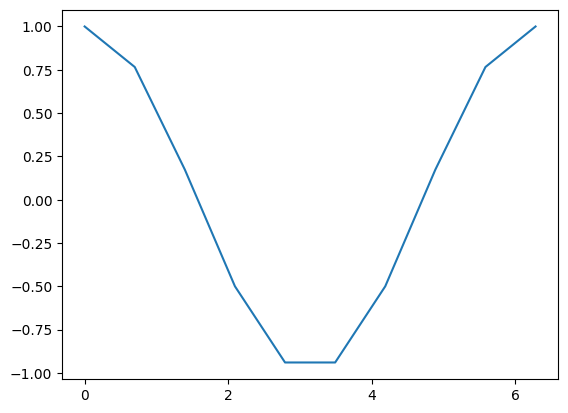

Generate + Pipeline:  52%|█████▏    | 129/250 [03:09<02:04,  1.03s/it]

--------------------------
DS0534
plt.xticks(np.arange(0, 2 * np.pi, 2))
pipeline output {'dataset': 'ds1000', 'task_id': 'DS0534', 'status': 'passed', 'ast_info': {'ast_parsed': True, 'ast_errors': []}, 'dynamic_info': {'status': 'passed', 'error_type': '', 'error_message': '', 'line_number': '', 'test_case': '', 'testcase_output': '', 'generated_code': 'plt.xticks(np.arange(0, 2 * np.pi, 2))'}, 'lib_info': None, 'generated_code': 'plt.xticks(np.arange(0, 2 * np.pi, 2))', 'patched_code': 'plt.xticks(np.arange(0, 2 * np.pi, 2))', 'error_sources': '', 'error_types': '', 'error_lines': '', 'canonical_solution': 'minx = x.min()\nmaxx = x.max()\nplt.xticks(np.arange(minx, maxx, step=2))'}
-----------x----------------


<string>:17: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

<string>:18: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

<string>:8: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `hi

--------------------------
DS0535
plt.legend()
pipeline output {'dataset': 'ds1000', 'task_id': 'DS0535', 'status': 'passed', 'ast_info': {'ast_parsed': True, 'ast_errors': []}, 'dynamic_info': {'status': 'passed', 'error_type': '', 'error_message': '', 'line_number': '', 'test_case': '', 'testcase_output': '', 'generated_code': 'plt.legend()'}, 'lib_info': None, 'generated_code': 'plt.legend()', 'patched_code': 'plt.legend()', 'error_sources': '', 'error_types': '', 'error_lines': '', 'canonical_solution': 'plt.legend()'}
-----------x----------------


Generate + Pipeline:  52%|█████▏    | 131/250 [03:10<01:30,  1.32it/s]

...

--------------------------
DS0553
plt.xticks([3, 4])
plt.grid(axis='x', linestyle='--', linewidth=0.5, color='gray')
pipeline output {'dataset': 'ds1000', 'task_id': 'DS0553', 'status': 'passed', 'ast_info': {'ast_parsed': True, 'ast_errors': []}, 'dynamic_info': {'status': 'passed', 'error_type': '', 'error_message': '', 'line_number': '', 'test_case': '', 'testcase_output': '', 'generated_code': "plt.xticks([3, 4])\nplt.grid(axis='x', linestyle='--', linewidth=0.5, color='gray')"}, 'lib_info': None, 'generated_code': "plt.xticks([3, 4])\nplt.grid(axis='x', linestyle='--', linewidth=0.5, color='gray')", 'patched_code': "plt.xticks([3, 4])\nplt.grid(axis='x', linestyle='--', linewidth=0.5, color='gray')", 'error_sources': '', 'error_types': '', 'error_lines': '', 'canonical_solution': 'ax = plt.gca()\n# ax.set_yticks([-1, 1])\nax.xaxis.set_ticks([3, 4])\nax.xaxis.grid(True)'}
-----------x----------------


Generate + Pipeline:  54%|█████▍    | 135/250 [03:17<02:53,  1.51s/it]

--------------------------
DS0554
plt.yticks(np.arange(-5, 6))
plt.grid(axis='y', linestyle='--', linewidth=0.5, color='gray', alpha=0.7, markevery=[3, 4])
pipeline output {'dataset': 'ds1000', 'task_id': 'DS0554', 'status': 'hallucinated', 'ast_info': {'ast_parsed': True, 'ast_errors': []}, 'dynamic_info': {'status': 'failed', 'error_type': 'AssertionError', 'error_message': '\nArrays are not equal\n\n(shapes (2,), (11,) mismatch)\n ACTUAL: array([3, 4])\n DESIRED: array([-5, -4, -3, -2, -1,  0,  1,  2,  3,  4,  5])', 'line_number': '', 'test_case': '[["None", "None", "<Execution Error: name \'plt\' is not defined>"], ["None", "None", "<Execution Error: name \'plt\' is not defined>"], ["None", "None", "<Execution Error: name \'plt\' is not defined>"], ["None", "None", "<Execution Error: name \'plt\' is not defined>"], ["None", "None", "<Execution Error: name \'plt\' is not defined>"], ["None", "None", "<Execution Error: name \'plt\' is not defined>"], ["None", "None", "<Execution Erro

Generate + Pipeline:  54%|█████▍    | 136/250 [03:17<02:24,  1.27s/it]

--------------------------
DS0561
plt.plot(x, y)
plt.xlabel("X", labelpad=20)
pipeline output {'dataset': 'ds1000', 'task_id': 'DS0561', 'status': 'passed', 'ast_info': {'ast_parsed': True, 'ast_errors': []}, 'dynamic_info': {'status': 'passed', 'error_type': '', 'error_message': '', 'line_number': '', 'test_case': '', 'testcase_output': '', 'generated_code': 'plt.plot(x, y)\nplt.xlabel("X", labelpad=20)'}, 'lib_info': None, 'generated_code': 'plt.plot(x, y)\nplt.xlabel("X", labelpad=20)', 'patched_code': 'plt.plot(x, y)\nplt.xlabel("X", labelpad=20)', 'error_sources': '', 'error_types': '', 'error_lines': '', 'canonical_solution': 'plt.plot(x, y)\nplt.xlabel("X", labelpad=20)\nplt.tight_layout()'}
-----------x----------------


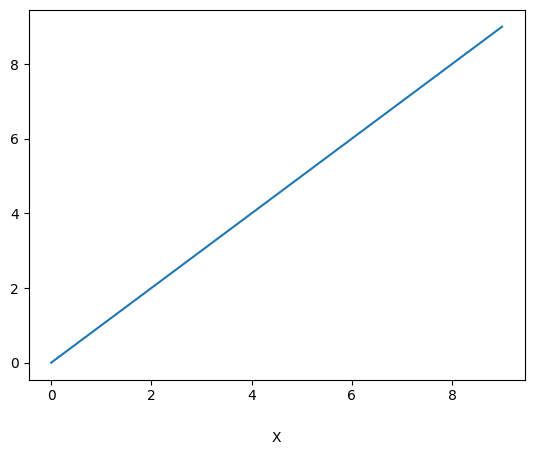

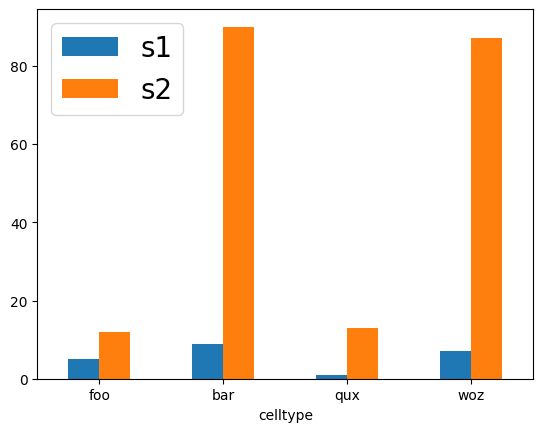

Generate + Pipeline:  55%|█████▍    | 137/250 [03:19<02:18,  1.23s/it]

--------------------------
DS0568
ax = df.plot.bar(x="celltype", y=["s1", "s2"], rot=0)
plt.xlabel("celltype")
pipeline output {'dataset': 'ds1000', 'task_id': 'DS0568', 'status': 'passed', 'ast_info': {'ast_parsed': True, 'ast_errors': []}, 'dynamic_info': {'status': 'passed', 'error_type': '', 'error_message': '', 'line_number': '', 'test_case': '', 'testcase_output': '', 'generated_code': 'ax = df.plot.bar(x="celltype", y=["s1", "s2"], rot=0)\nplt.xlabel("celltype")'}, 'lib_info': None, 'generated_code': 'ax = df.plot.bar(x="celltype", y=["s1", "s2"], rot=0)\nplt.xlabel("celltype")', 'patched_code': 'ax = df.plot.bar(x="celltype", y=["s1", "s2"], rot=0)\nplt.xlabel("celltype")', 'error_sources': '', 'error_types': '', 'error_lines': '', 'canonical_solution': 'df = df[["celltype", "s1", "s2"]]\ndf.set_index(["celltype"], inplace=True)\ndf.plot(kind="bar", alpha=0.75, rot=0)'}
-----------x----------------


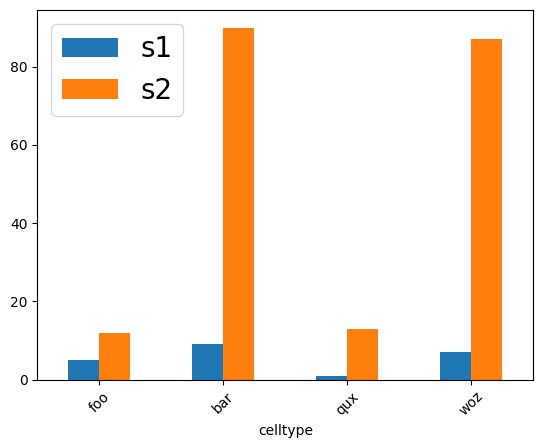

Generate + Pipeline:  55%|█████▌    | 138/250 [03:20<02:14,  1.20s/it]

--------------------------
DS0569
ax = df.plot.bar(x="celltype", y=["s1", "s2"], rot=45)
plt.xlabel("celltype")
pipeline output {'dataset': 'ds1000', 'task_id': 'DS0569', 'status': 'passed', 'ast_info': {'ast_parsed': True, 'ast_errors': []}, 'dynamic_info': {'status': 'passed', 'error_type': '', 'error_message': '', 'line_number': '', 'test_case': '', 'testcase_output': '', 'generated_code': 'ax = df.plot.bar(x="celltype", y=["s1", "s2"], rot=45)\nplt.xlabel("celltype")'}, 'lib_info': None, 'generated_code': 'ax = df.plot.bar(x="celltype", y=["s1", "s2"], rot=45)\nplt.xlabel("celltype")', 'patched_code': 'ax = df.plot.bar(x="celltype", y=["s1", "s2"], rot=45)\nplt.xlabel("celltype")', 'error_sources': '', 'error_types': '', 'error_lines': '', 'canonical_solution': 'df = df[["celltype", "s1", "s2"]]\ndf.set_index(["celltype"], inplace=True)\ndf.plot(kind="bar", alpha=0.75, rot=45)'}
-----------x----------------


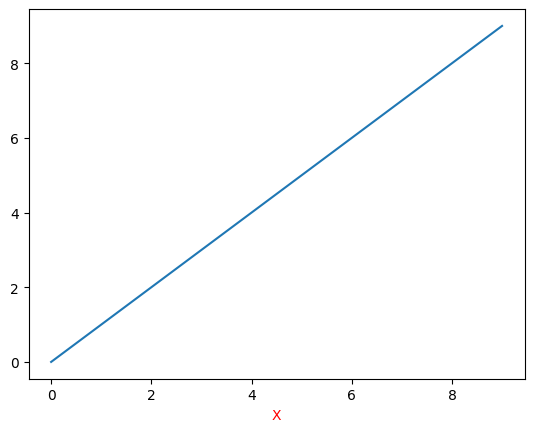

Generate + Pipeline:  56%|█████▌    | 139/250 [03:21<02:10,  1.18s/it]

--------------------------
DS0570
plt.plot(x, y)
plt.xlabel("X", color='red')
pipeline output {'dataset': 'ds1000', 'task_id': 'DS0570', 'status': 'hallucinated', 'ast_info': {'ast_parsed': True, 'ast_errors': []}, 'dynamic_info': {'status': 'failed', 'error_type': 'KeyError', 'error_message': "'color'", 'line_number': '36', 'test_case': '[["None", "None", "<Execution Error: name \'plt\' is not defined>"], ["None", "None", "<Execution Error: name \'plt\' is not defined>"], ["None", "None", "<Execution Error: name \'plt\' is not defined>"], ["None", "None", "<Execution Error: name \'plt\' is not defined>"], ["None", "None", "<Execution Error: name \'plt\' is not defined>"], ["None", "None", "<Execution Error: name \'plt\' is not defined>"], ["None", "None", "<Execution Error: name \'plt\' is not defined>"], ["None", "None", "<Execution Error: name \'plt\' is not defined>"], ["None", "None", "<Execution Error: name \'plt\' is not defined>"]]', 'testcase_output': '', 'generated_code': 'pl

Generate + Pipeline:  56%|█████▌    | 140/250 [03:22<01:59,  1.09s/it]

--------------------------
DS0572
plt.plot(x, y)
plt.tick_params(axis='x', labelsize=10, rotation=90)
pipeline output {'dataset': 'ds1000', 'task_id': 'DS0572', 'status': 'passed', 'ast_info': {'ast_parsed': True, 'ast_errors': []}, 'dynamic_info': {'status': 'passed', 'error_type': '', 'error_message': '', 'line_number': '', 'test_case': '', 'testcase_output': '', 'generated_code': "plt.plot(x, y)\nplt.tick_params(axis='x', labelsize=10, rotation=90)"}, 'lib_info': None, 'generated_code': "plt.plot(x, y)\nplt.tick_params(axis='x', labelsize=10, rotation=90)", 'patched_code': "plt.plot(x, y)\nplt.tick_params(axis='x', labelsize=10, rotation=90)", 'error_sources': '', 'error_types': '', 'error_lines': '', 'canonical_solution': 'plt.plot(y, x)\nplt.xticks(fontsize=10, rotation=90)'}
-----------x----------------


Generate + Pipeline:  56%|█████▋    | 141/250 [03:25<03:18,  1.83s/it]

...

--------------------------
DS0577
sns.scatterplot(data=df, x="bill_length_mm", y="bill_depth_mm", s=30)
pipeline output {'dataset': 'ds1000', 'task_id': 'DS0577', 'status': 'hallucinated', 'ast_info': {'ast_parsed': True, 'ast_errors': []}, 'dynamic_info': {'status': 'failed', 'error_type': 'AttributeError', 'error_message': "'LineCollection' object has no attribute 'get_sizes'", 'line_number': '24', 'test_case': '[["None", "None", "<Execution Error: name \'sns\' is not defined>"], ["None", "None", "<Execution Error: name \'sns\' is not defined>"], ["None", "None", "<Execution Error: name \'sns\' is not defined>"], ["None", "None", "<Execution Error: name \'sns\' is not defined>"], ["None", "None", "<Execution Error: name \'sns\' is not defined>"], ["None", "None", "<Execution Error: name \'sns\' is not defined>"], ["None", "None", "<Execution Error: name \'sns\' is not defined>"], ["None", "None", "<Execution Error: name \'sns\' is not defined>"], ["None", "None", "<Execution Error: n

Generate + Pipeline:  58%|█████▊    | 144/250 [03:30<02:35,  1.47s/it]

--------------------------
DS0579
plt.plot(x, y, label="y over x")
plt.legend(title="Legend")
pipeline output {'dataset': 'ds1000', 'task_id': 'DS0579', 'status': 'passed', 'ast_info': {'ast_parsed': True, 'ast_errors': []}, 'dynamic_info': {'status': 'passed', 'error_type': '', 'error_message': '', 'line_number': '', 'test_case': '', 'testcase_output': '', 'generated_code': 'plt.plot(x, y, label="y over x")\nplt.legend(title="Legend")'}, 'lib_info': None, 'generated_code': 'plt.plot(x, y, label="y over x")\nplt.legend(title="Legend")', 'patched_code': 'plt.plot(x, y, label="y over x")\nplt.legend(title="Legend")', 'error_sources': '', 'error_types': '', 'error_lines': '', 'canonical_solution': 'plt.plot(x, y, label="y over x")\nplt.legend(title="legend")'}
-----------x----------------


Generate + Pipeline:  58%|█████▊    | 145/250 [03:33<03:26,  1.96s/it]

--------------------------
DS0584
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

x = np.random.rand(10)
y = np.random.rand(10)

plt.hist([x, y], bins=10, stacked=True)
plt.savefig('output.png', bbox_inches='tight')
result = None
pipeline output {'dataset': 'ds1000', 'task_id': 'DS0584', 'status': 'hallucinated', 'ast_info': {'ast_parsed': True, 'ast_errors': []}, 'dynamic_info': {'status': 'failed', 'error_type': 'AssertionError', 'error_message': '', 'line_number': '', 'test_case': '[["None", "None", "None"], ["None", "None", "None"], ["None", "None", "None"], ["None", "None", "None"], ["None", "None", "None"], ["None", "None", "None"], ["None", "None", "None"], ["None", "None", "None"], ["None", "None", "None"]]', 'testcase_output': 'Traceback (most recent call last):\n  File "/tmp/ipykernel_5183/3661587577.py", line 89, in execute_ds1000_test_inner\n    test_env[\'test_execution\'](generated_code)\n  File "<string>", line 65, in test_execution\n  File "<stri

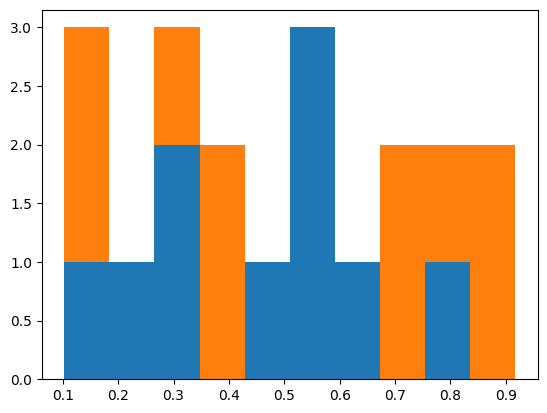

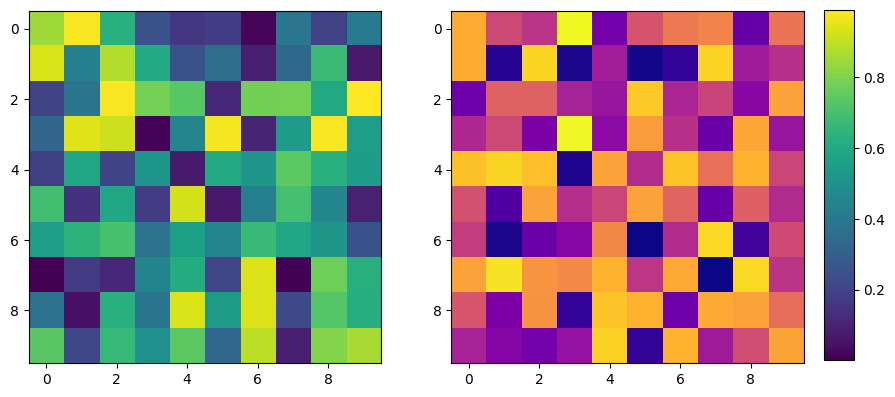

Generate + Pipeline:  58%|█████▊    | 146/250 [03:37<04:41,  2.71s/it]

--------------------------
DS0586
import matplotlib.pyplot as plt
import numpy as np
x = np.random.random((10, 10))
y = np.random.random((10, 10))
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
cax = fig.add_axes([0.92, 0.15, 0.03, 0.7])
im1 = axs[0].imshow(x, cmap='viridis')
im2 = axs[1].imshow(y, cmap='plasma')
fig.colorbar(im1, cax=cax)
plt.savefig('output.png', bbox_inches ='tight')
result = None
pipeline output {'dataset': 'ds1000', 'task_id': 'DS0586', 'status': 'passed', 'ast_info': {'ast_parsed': True, 'ast_errors': []}, 'dynamic_info': {'status': 'passed', 'error_type': '', 'error_message': '', 'line_number': '', 'test_case': '', 'testcase_output': '', 'generated_code': "import matplotlib.pyplot as plt\nimport numpy as np\nx = np.random.random((10, 10))\ny = np.random.random((10, 10))\nfig, axs = plt.subplots(1, 2, figsize=(10, 5))\ncax = fig.add_axes([0.92, 0.15, 0.03, 0.7])\nim1 = axs[0].imshow(x, cmap='viridis')\nim2 = axs[1].imshow(y, cmap='plasma')\nfig.colorbar(im1, cax=

Generate + Pipeline:  59%|█████▉    | 147/250 [03:39<04:10,  2.43s/it]

--------------------------
DS0588
fig, axs = plt.subplots(2, 1)
axs[0].plot(x, y)
axs[1].plot(a, z)
fig.suptitle("Y and Z")
plt.savefig('output.png', bbox_inches='tight')
pipeline output {'dataset': 'ds1000', 'task_id': 'DS0588', 'status': 'passed', 'ast_info': {'ast_parsed': True, 'ast_errors': []}, 'dynamic_info': {'status': 'passed', 'error_type': '', 'error_message': '', 'line_number': '', 'test_case': '', 'testcase_output': '', 'generated_code': 'fig, axs = plt.subplots(2, 1)\naxs[0].plot(x, y)\naxs[1].plot(a, z)\nfig.suptitle("Y and Z")\nplt.savefig(\'output.png\', bbox_inches=\'tight\')'}, 'lib_info': None, 'generated_code': 'fig, axs = plt.subplots(2, 1)\naxs[0].plot(x, y)\naxs[1].plot(a, z)\nfig.suptitle("Y and Z")\nplt.savefig(\'output.png\', bbox_inches=\'tight\')', 'patched_code': 'fig, axs = plt.subplots(2, 1)\naxs[0].plot(x, y)\naxs[1].plot(a, z)\nfig.suptitle("Y and Z")\nplt.savefig(\'output.png\', bbox_inches=\'tight\')', 'error_sources': '', 'error_types': '', 'error_l

Generate + Pipeline:  59%|█████▉    | 148/250 [03:40<03:36,  2.12s/it]

...

--------------------------
DS0991
import numpy as np
import pandas as pd
import torch
x, y = test_input
signed_max = torch.where(torch.abs(x) > torch.abs(y), x, y) * torch.sign(x)
result = signed_max
pipeline output {'dataset': 'ds1000', 'task_id': 'DS0991', 'status': 'hallucinated', 'ast_info': {'ast_parsed': True, 'ast_errors': []}, 'dynamic_info': {'status': 'failed', 'error_type': 'AssertionError', 'error_message': '', 'line_number': '', 'test_case': '[["(tensor([-8, -3,  6,  4, -4]), tensor([ -5,   0, -16,  10,  13]))", "tensor([ -8,  -3, -16,  10,  13])", "tensor([  8,   3, -16,  10, -13])"]]', 'testcase_output': 'Traceback (most recent call last):\n  File "/tmp/ipykernel_5183/3661587577.py", line 89, in execute_ds1000_test_inner\n    test_env[\'test_execution\'](generated_code)\n  File "<string>", line 51, in test_execution\nAssertionError\n', 'generated_code': 'import numpy as np\nimport pandas as pd\nimport torch\nx, y = test_input\nsigned_max = torch.where(torch.abs(x) > torc

Generate + Pipeline: 100%|█████████▉| 249/250 [06:24<00:01,  1.24s/it]

--------------------------
DS0994
result = torch.cat((torch.mean(torch.stack([a[:, :-1], b[:, 1:]], dim=0), dim=0), a[:, -1:]), dim=1)
pipeline output {'dataset': 'ds1000', 'task_id': 'DS0994', 'status': 'hallucinated', 'ast_info': {'ast_parsed': True, 'ast_errors': []}, 'dynamic_info': {'status': 'failed', 'error_type': 'AssertionError', 'error_message': '', 'line_number': '', 'test_case': '[["(tensor([[1., 2., 3.],\\n        [1., 2., 3.]]), tensor([[5., 6., 7.],\\n        [5., 6., 7.]]))", "tensor([[1., 2., 4., 6., 7.],\\n        [1., 2., 4., 6., 7.]])", "<Execution Error: name \'torch\' is not defined>"], ["(tensor([[3., 2., 1.],\\n        [1., 2., 3.]]), tensor([[7., 6., 5.],\\n        [5., 6., 7.]]))", "tensor([[3., 2., 4., 6., 5.],\\n        [1., 2., 4., 6., 7.]])", "<Execution Error: name \'torch\' is not defined>"], ["(tensor([[3., 2., 1., 1., 2.],\\n        [1., 1., 1., 2., 3.],\\n        [9., 9., 5., 6., 7.]]), tensor([[1., 4., 7., 6., 5.],\\n        [9., 9., 5., 6., 7.],\\n 

Generate + Pipeline: 100%|██████████| 250/250 [06:25<00:00,  1.54s/it]

tensor([[-1, -1,  1,  2],
        [-1, -1,  3,  4],
        [-1, -1,  5,  6],
        [-1, -1,  7,  8]])
--------------------------
DS0998
def solution(t):
    return torch.cat((torch.ones_like(t) * -1, t), dim=1)

result = solution(t)
print(result)
pipeline output {'dataset': 'ds1000', 'task_id': 'DS0998', 'status': 'hallucinated', 'ast_info': {'ast_parsed': True, 'ast_errors': []}, 'dynamic_info': {'status': 'failed', 'error_type': 'AssertionError', 'error_message': '', 'line_number': '', 'test_case': '[["tensor([[1, 2],\\n        [3, 4],\\n        [5, 6],\\n        [7, 8]])", "tensor([[-1., -1., -1., -1.],\\n        [-1.,  1.,  2., -1.],\\n        [-1.,  3.,  4., -1.],\\n        [-1.,  5.,  6., -1.],\\n        [-1.,  7.,  8., -1.],\\n        [-1., -1., -1., -1.]])", "<Execution Error: name \'t\' is not defined>"], ["tensor([[ 5,  6,  7],\\n        [ 2,  3,  4],\\n        [ 1,  2,  3],\\n        [ 7,  8,  9],\\n        [10, 11, 12]])", "tensor([[-1., -1., -1., -1., -1.],\\n        [-

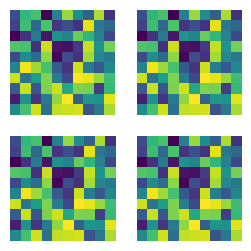

In [19]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)
model_device = next(model.parameters()).device
results = []
for idx, row in tqdm(df.iterrows(), total=len(df), desc="Generate + Pipeline"):
    raw_prompt = row.get("prompt_2", row.get("prompt", ""))
    exec_snippet = extract_only_exec_context_wi(row.get("code_context", ""))
    formatted_messages = contruct_prompt_ds1k_v4(raw_prompt, exec_snippet)
    inputs = tokenizer.apply_chat_template(formatted_messages, add_generation_prompt=True, tokenize=True, return_dict=True, return_tensors="pt")
    inputs = {k: v.to(model_device) if isinstance(v, torch.Tensor) else v for k, v in inputs.items()}
    with torch.no_grad():
        outputs = model.generate(**inputs, max_new_tokens=512, do_sample=False, pad_token_id=tokenizer.eos_token_id)
    gen_ids = outputs[0][len(inputs["input_ids"][0]):]
    raw_response = tokenizer.decode(gen_ids, skip_special_tokens=True)
    generated_code = extract_python_code_humaneval(raw_response)
    row_dict = {"code_context": row.get("code_context", ""), "canonical_solution": row.get("reference_code", "")}
    row_dict["task_id"] = row["task_id"]
    pipeline_output = run_full_hallucination_pipeline(row_dict, "ds1000", row["task_id"], generated_code)
    print('--------------------------')
    print(row['task_id'])
    #print(formatted_messages)
    print(generated_code)
    print('pipeline output',pipeline_output)
    print('-----------x----------------')
    results.append(pipeline_output)
print(f"Done. {len(results)} pipeline results.")

In [20]:
results_df = pd.DataFrame(results)
def serialize_col(val):
    if val is None:
        return ""
    if isinstance(val, dict):
        return str(val)
    return str(val)
results_df["ast_info"] = results_df["ast_info"].map(serialize_col)
results_df["dynamic_info"] = results_df["dynamic_info"].map(serialize_col)
results_df["lib_info"] = results_df["lib_info"].map(serialize_col)
cols = ["dataset", "task_id", "status", "ast_info", "dynamic_info", "lib_info", "generated_code", "patched_code", "error_sources", "error_types", "error_lines"]
if "canonical_solution" in results_df.columns:
    cols = cols + ["canonical_solution"]
results_df = results_df[[c for c in cols if c in results_df.columns]]
out_dir = NOTEBOOK_DIR if "NOTEBOOK_DIR" in dir() else os.getcwd()
out_path = os.path.join(out_dir, "ds1000_adapter_pipeline_output.csv")
# Windows: saves locally; no Colab download widget
results_df.to_csv(out_path, index=False)
print(f"Saved to {out_path}")

Saved to /home/jovyan/TT/ALL VERIFICATION/FED_AVG/ds1000_adapter_pipeline_output.csv


## 8. Compare and optional breakdown

In [21]:
passed_sft = (results_df["status"] == "passed").sum()
total_sft = len(results_df)
pass_rate_sft = passed_sft / total_sft if total_sft else 0
print("=== Pass rate comparison ===")
print(f"Before SFT (from CSV): {pass_rate_baseline:.2%} ({passed_baseline}/{total_baseline})")
print(f"After SFT (adapters):  {pass_rate_sft:.2%} ({passed_sft}/{total_sft})")
diff = pass_rate_sft - pass_rate_baseline
print(f"Difference: {diff:+.2%}")
if pass_rate_sft > pass_rate_baseline:
    print("Conclusion: Adapter improves DS1000 pass@1.")
elif pass_rate_sft < pass_rate_baseline:
    print("Conclusion: Adapter pass rate is lower than baseline.")
else:
    print("Conclusion: Same pass rate.")

=== Pass rate comparison ===
Before SFT (from CSV): 18.40% (46/250)
After SFT (adapters):  30.40% (76/250)
Difference: +12.00%
Conclusion: Adapter improves DS1000 pass@1.


In [ ]:
# Compare adapter run to manifest expectations (set VERIFICATION_EXPECT_KEY above: fedavg_adapter vs federroravg_adapter)
if os.path.isfile(VERIFICATION_JSON_PATH) and "results_df" in dir() and len(results_df):
    import json
    with open(VERIFICATION_JSON_PATH, "r", encoding="utf-8") as f:
        _man = json.load(f)
    exp = (_man.get("expected") or {}).get(VERIFICATION_EXPECT_KEY, {})
    if exp:
        print(f"=== Manifest check ({VERIFICATION_EXPECT_KEY}) ===")
        ok = 0
        bad = []
        for tid, want in exp.items():
            row = results_df[results_df["task_id"].astype(str) == str(tid)]
            if row.empty:
                bad.append((tid, want, "missing"))
                continue
            got = str(row.iloc[0]["status"]).strip().lower()
            want_l = str(want).strip().lower()
            if got == want_l:
                ok += 1
                print(f"  OK {tid}: {got}")
            else:
                bad.append((tid, want, got))
                print(f"  MISMATCH {tid}: expected {want}, got {got}")
        print(f"Summary: {ok}/{len(exp)} matched")
        if bad:
            print("Failures:", bad)
    else:
        print(f"No expected.{VERIFICATION_EXPECT_KEY} in manifest; skip check.")
else:
    print("Manifest check skipped (no manifest, results_df, or empty run).")

In [22]:
from collections import Counter
failed = results_df[results_df["status"] != "passed"]
if len(failed) > 0 and "error_types" in failed.columns:
    breakdown = failed["error_types"].value_counts()
    print("After SFT failure breakdown (error_types):")
    for et, count in breakdown.head(15).items():
        print(f"  {count:3d}: {str(et)[:60]}")
else:
    print("After SFT: no failures or no error_types column.")

After SFT failure breakdown (error_types):
   78: 
   19: ValueError
   16: KeyError
   16: IndentationError
   15: TypeError
   11: NameError
    5: AttributeError
    5: InternalError
    3: IndexError
    2: AxisError
    2: NotFittedError
    2: RuntimeError


In [23]:
import pandas as pd

df_out = pd.DataFrame([{
    "num_tasks": total_sft,  # or total_baseline (they should be same ideally)
    "baseline_passed": passed_baseline,
    "baseline_pass_rate": pass_rate_baseline,
    "adapter_passed": passed_sft,
    "adapter_pass_rate": pass_rate_sft,
    "difference": diff
}])

df_out.to_csv("pass_rate_comparison_clean_ds1000.csv", index=False)

print("Saved to pass_rate_comparison_clean_ds1000.csv")

Saved to pass_rate_comparison_clean_ds1000.csv
